# Carbon budget outcome — grid × CCS matrix

The sixteen cells compared against the constructed smelting budget, as cumulative emissions
over time and as 2050 cumulative bars, for smelting alone and for smelting plus refining.
Colour is the IAM grid; line style is the CCS regime. Refining is inert to both levers, so it
enters as a fixed offset (one shared refinery run).

In [1]:
import sys, importlib
sys.path.append("../..")
import common; importlib.reload(common)

import matplotlib.pyplot as plt
import pandas as pd
from common import (GRIDS, CCS_ORDER, CCS_LABELS, GRID_COLOURS, run_name,
                    emissions, budget, style, save)

style()
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Line style carries the CCS regime; colour carries the grid.
CCS_STYLE = {"none": ":", "low": "-.", "high": "--", "unlimited": "-"}

In [2]:
# Cumulative emissions (Gt) for each cell: smelting alone, and smelting + refining.
cum_smelting, cum_combined = {}, {}
for grid in GRIDS:
    for ccs in CCS_ORDER:
        n = run_name(grid, ccs)
        smelt = emissions(n, "smelter")
        refine = emissions(n, "refinery")               # redirects to the shared refinery run
        cum_smelting[(grid, ccs)] = smelt.cumsum() / 1000
        cum_combined[(grid, ccs)] = (smelt + refine).cumsum() / 1000

budget_smelting = budget("smelter").cumsum() / 1000
budget_combined = (budget("smelter") + budget("refinery")).cumsum() / 1000
print(f"smelting budget {budget_smelting.loc[2050]:.2f} Gt, "
      f"combined {budget_combined.loc[2050]:.2f} Gt")

smelting budget 12.75 Gt, combined 14.59 Gt


## Cumulative emissions over time

wrote figures/budget_cumulative_over_time.png and .svg


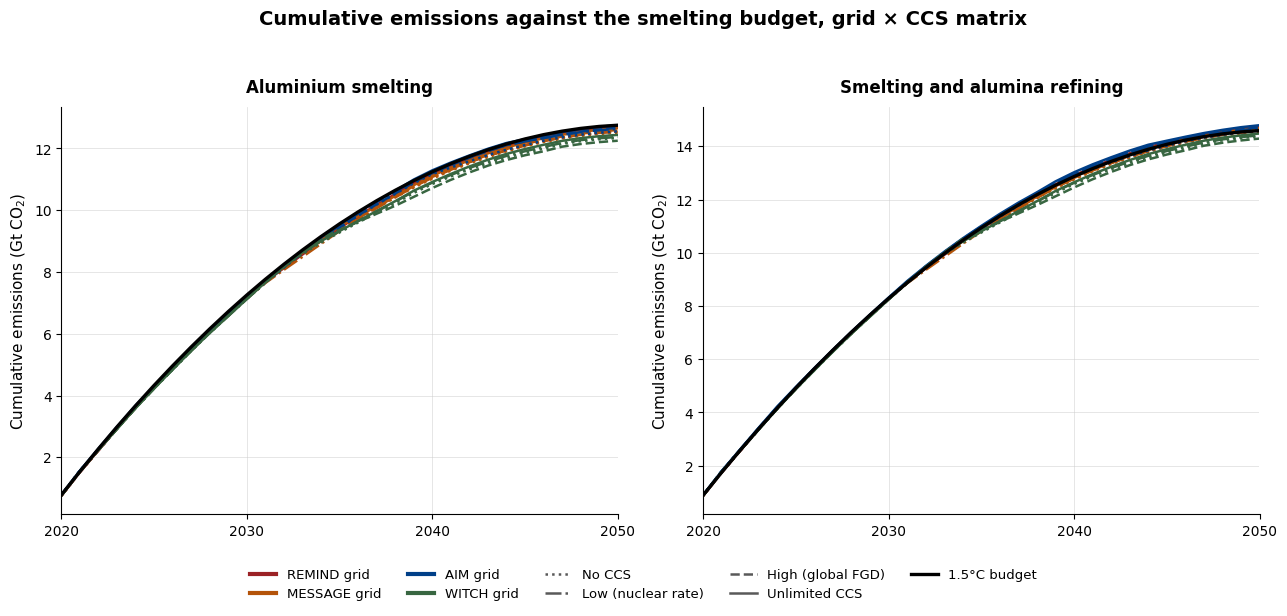

In [3]:
PANELS = [("Aluminium smelting", cum_smelting, budget_smelting),
          ("Smelting and alumina refining", cum_combined, budget_combined)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.8), sharex=True)
for ax, (title, series, budget_line) in zip(axes, PANELS):
    for grid in GRIDS:
        for ccs in CCS_ORDER:
            line = series[(grid, ccs)]
            ax.plot(line.index, line.values, color=GRID_COLOURS[grid],
                    linestyle=CCS_STYLE[ccs], linewidth=1.8)
    ax.plot(budget_line.index, budget_line.values, color="black", linewidth=2.4,
            label="1.5\u00b0C budget")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlim(2020, 2050); ax.set_xticks(range(2020, 2051, 10))
    ax.set_ylabel("Cumulative emissions (Gt CO$_2$)")

# Two legends: grid = colour, CCS regime = line style
from matplotlib.lines import Line2D
grid_handles = [Line2D([0], [0], color=GRID_COLOURS[g], lw=3, label=f"{g} grid") for g in GRIDS]
ccs_handles = [Line2D([0], [0], color="0.35", lw=1.8, linestyle=CCS_STYLE[c],
               label=CCS_LABELS[c].replace("\n", " ")) for c in CCS_ORDER]
budget_handle = [Line2D([0], [0], color="black", lw=2.4, label="1.5\u00b0C budget")]
fig.legend(handles=grid_handles + ccs_handles + budget_handle, loc="lower center",
           ncol=5, frameon=False, fontsize=9.5, bbox_to_anchor=(0.5, -0.04))
fig.suptitle("Cumulative emissions against the smelting budget, grid \u00d7 CCS matrix",
             fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout(rect=[0, 0.06, 1, 0.97])
save(fig, "budget_cumulative_over_time")
plt.show()

## 2050 cumulative against budget — bars

wrote figures/budget_total_bars.png and .svg


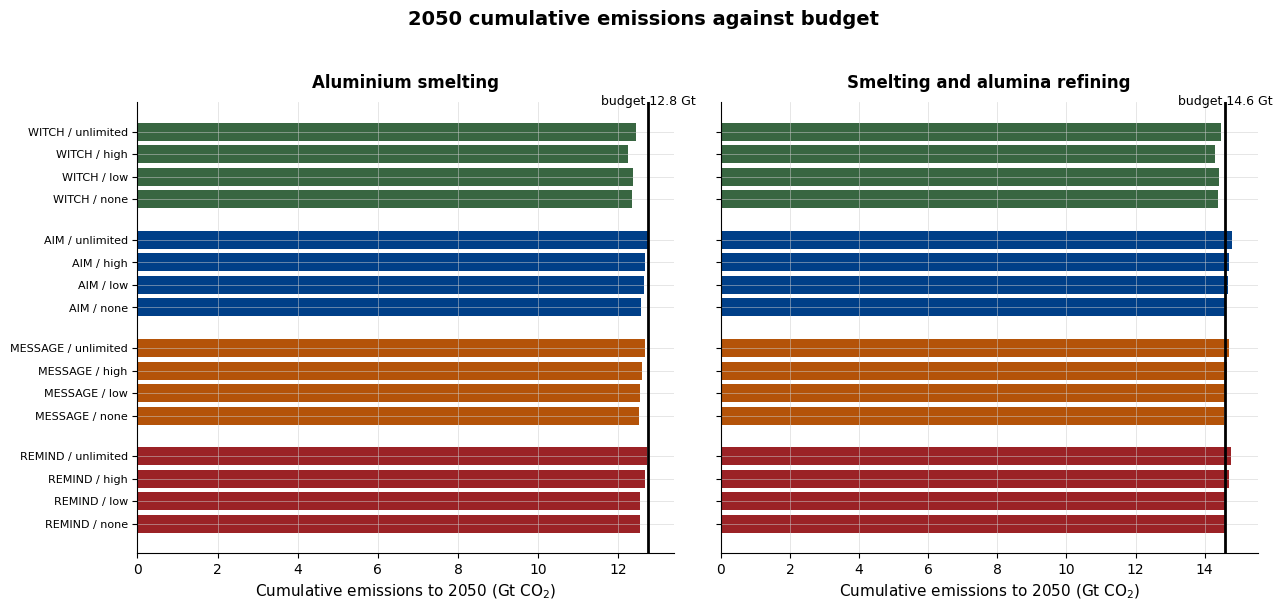

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6.2), sharey=True)
for ax, (title, series, budget_line) in zip(axes, PANELS):
    total_budget = budget_line.loc[2050]
    labels, values, colours, positions = [], [], [], []
    y = 0.0
    for grid in GRIDS:
        for ccs in CCS_ORDER:
            labels.append(f"{grid} / {ccs}")
            values.append(series[(grid, ccs)].loc[2050])
            colours.append(GRID_COLOURS[grid])
            positions.append(y); y += 1
        y += 0.8            # gap between grid groups
    ax.barh(positions, values, color=colours, height=0.8)
    ax.axvline(total_budget, color="black", linewidth=2.0)
    ax.text(total_budget, max(positions) + 1.2, f"budget {total_budget:.1f} Gt",
            fontsize=9, ha="center")
    ax.set_yticks(positions); ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("Cumulative emissions to 2050 (Gt CO$_2$)")
    ax.set_title(title, fontsize=12, fontweight="bold")
fig.suptitle("2050 cumulative emissions against budget", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.96])
save(fig, "budget_total_bars")
plt.show()

## Capture by how the plant got there — newbuild vs retrofit

Power-capture production in 2050, split by whether the capture-equipped plant was a new build
(greenfield or rebuild) or an existing plant retrofitted in place (brownfield renovation). The
retrofit-vs-newbuild share bears on whether greenfield captive fossil+CCS should be allowed at
all (open item O4): a result that leans on newbuild capture in the 2040s is the less credible
one. Two terracotta shades: darker = retrofit, lighter = newbuild.

In [5]:
from pathlib import Path
import glob

def capture_split(grid, ccs):
    """2050 power-capture production (Mt), split into newbuild and retrofit by entry path."""
    n = run_name(grid, ccs)
    path = glob.glob(f"../../runs/{n}/smelter/final/plant_stack_transition_*.csv")[0]
    d = pd.read_csv(path).sort_values(["uuid", "year"])
    # power capture = the power half of "<anode> + <power>" ends with +CCS
    d["pcap"] = d["technology"].str.split(" + ", n=1, regex=False).str[1].fillna("").str.endswith("+CCS")
    cap2050 = set(d[(d["year"] == 2050) & d["pcap"]]["uuid"])
    newbuild = retrofit = 0.0
    for uuid, g in d[d["uuid"].isin(cap2050)].groupby("uuid"):
        first = g[g["pcap"]].iloc[0]                     # year this plant first became capture
        if first["retrofit_status"]:
            retrofit += first["annual_production_volume"]
        else:                                            # greenfield or rebuild
            newbuild += first["annual_production_volume"]
    return newbuild, retrofit

TERRACOTTA_NEW = "#e6a17a"     # lighter: newbuild
TERRACOTTA_RETRO = "#a83e2c"   # darker: retrofit

wrote figures/budget_capture_newbuild_vs_retrofit.png and .svg


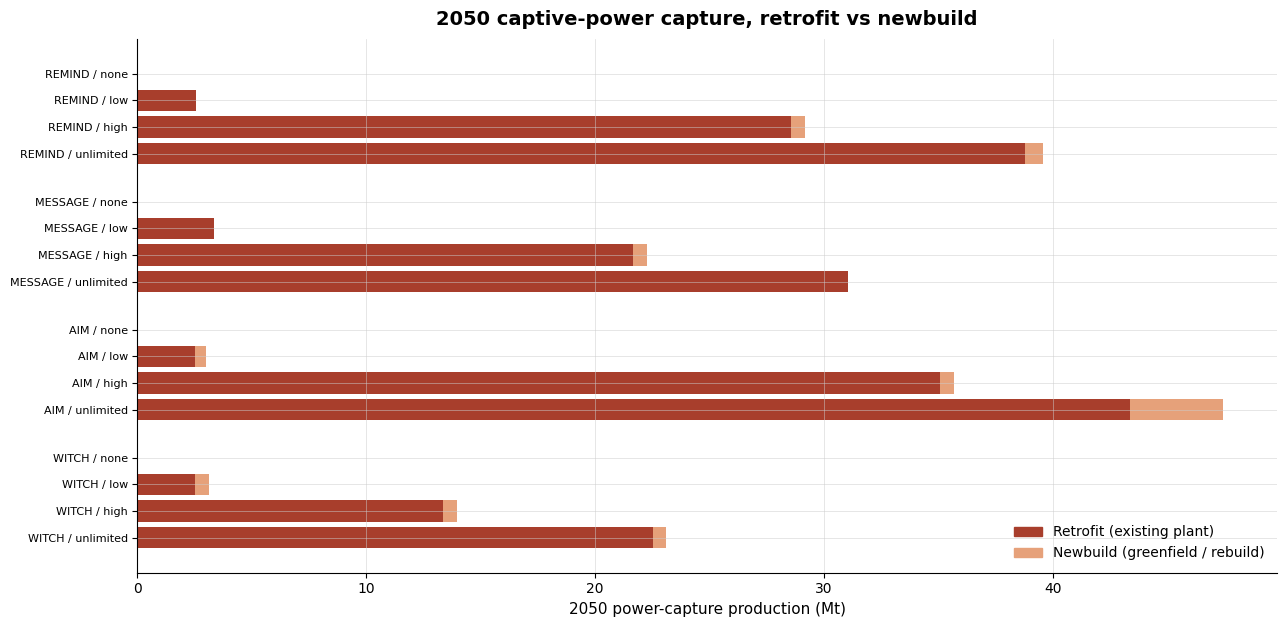

In [6]:
fig, ax = plt.subplots(figsize=(13, 6.4))
labels, positions = [], []
y = 0.0
for grid in GRIDS:
    for ccs in CCS_ORDER:
        nb_mt, rf_mt = capture_split(grid, ccs)
        ax.barh(y, rf_mt, color=TERRACOTTA_RETRO, height=0.8)
        ax.barh(y, nb_mt, left=rf_mt, color=TERRACOTTA_NEW, height=0.8)
        labels.append(f"{grid} / {ccs}"); positions.append(y); y += 1
    y += 0.8
ax.set_yticks(positions); ax.set_yticklabels(labels, fontsize=8); ax.invert_yaxis()
ax.set_xlabel("2050 power-capture production (Mt)")
ax.set_title("2050 captive-power capture, retrofit vs newbuild", fontsize=14, fontweight="bold")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=TERRACOTTA_RETRO, label="Retrofit (existing plant)"),
                   Patch(color=TERRACOTTA_NEW, label="Newbuild (greenfield / rebuild)")],
          frameon=False, fontsize=10, loc="lower right")
fig.tight_layout()
save(fig, "budget_capture_newbuild_vs_retrofit")
plt.show()

In [7]:
# Table form of the same split
rows = []
for grid in GRIDS:
    for ccs in CCS_ORDER:
        nb_mt, rf_mt = capture_split(grid, ccs)
        tot = nb_mt + rf_mt
        rows.append({"Grid": grid, "CCS regime": CCS_LABELS[ccs].replace("\n", " "),
                     "Retrofit Mt": rf_mt, "Newbuild Mt": nb_mt,
                     "Newbuild share %": (100 * nb_mt / tot) if tot > 0 else 0.0})
pd.DataFrame(rows)

,Grid,CCS regime,Retrofit Mt,Newbuild Mt,Newbuild share %
0,REMIND,No CCS,0.00,0.00,0.00
1,REMIND,Low (nuclear rate),2.55,0.00,0.00
2,REMIND,High (global FGD),28.56,0.60,2.06
3,REMIND,Unlimited CCS,38.80,0.77,1.94
4,MESSAGE,No CCS,0.00,0.00,0.00
5,MESSAGE,Low (nuclear rate),3.35,0.00,0.00
6,MESSAGE,High (global FGD),21.67,0.60,2.69
7,MESSAGE,Unlimited CCS,31.06,0.00,0.00
8,AIM,No CCS,0.00,0.00,0.00
9,AIM,Low (nuclear rate),2.50,0.52,17.12


## Summary table

In [8]:
rows = []
for grid in GRIDS:
    for ccs in CCS_ORDER:
        s = cum_smelting[(grid, ccs)].loc[2050]
        c = cum_combined[(grid, ccs)].loc[2050]
        rows.append({"Grid": grid, "CCS regime": CCS_LABELS[ccs].replace("\n", " "),
                     "Smelting Gt": s,
                     "vs smelting budget %": 100 * (s / budget_smelting.loc[2050] - 1),
                     "Combined Gt": c,
                     "vs combined budget %": 100 * (c / budget_combined.loc[2050] - 1)})
pd.DataFrame(rows)

,Grid,CCS regime,Smelting Gt,vs smelting budget %,Combined Gt,vs combined budget %
0,REMIND,No CCS,12.55,-1.59,14.59,0.01
1,REMIND,Low (nuclear rate),12.55,-1.57,14.59,0.03
2,REMIND,High (global FGD),12.67,-0.63,14.71,0.86
3,REMIND,Unlimited CCS,12.71,-0.31,14.75,1.13
4,MESSAGE,No CCS,12.51,-1.89,14.55,-0.25
5,MESSAGE,Low (nuclear rate),12.55,-1.61,14.59,-0.00
6,MESSAGE,High (global FGD),12.60,-1.21,14.64,0.34
7,MESSAGE,Unlimited CCS,12.65,-0.77,14.69,0.73
8,AIM,No CCS,12.55,-1.55,14.59,0.05
9,AIM,Low (nuclear rate),12.63,-0.92,14.67,0.60
